# LangChain Agents, Local LLMs (Ollama: Qwen, Gemma)

Concise, agent-focused notebook. Uses **LangChain** with **Ollama** (Qwen, Gemma) locally.

**Some of the items in this tutorial:**
- Run local chat models via Ollama.
- Define tools and build **ReAct** agents.
- Control iterations, handle parsing errors, and debug.
- EDA agent with tools


## Table of Contents
1. [Prerequisites](#prereqs)
2. [Verify Ollama & Pull Models](#verify)
3. [Initialize LLMs & Embeddings](#init)
4. [Define Tools](#tools)
5. [Minimal ReAct Agent](#minimal)
6. [Multi-Tool Agent](#multi)
7. [EDA Agent](#eda)


## 1) Prerequisites <a id='prereqs'></a>

Install Python packages (uncomment to run if needed):

```bash
# !pip install -U langchain langchain-community langchain-ollama faiss-cpu tiktoken
# !pip install -U langchain-text-splitters pydantic requests
```

Install **Ollama** from https://ollama.com/download and ensure the service is running.

In [1]:
!pip install -U langchain langchain-community langchain-ollama faiss-cpu tiktoken
!pip install -U langchain-text-splitters pydantic requests

## 2) Verify Ollama, Pull Models & Imports <a id='verify'></a>

The following cell checks whether Ollama is responding locally and lists installed models.
If models are missing, pull them (uncomment the `ollama pull` commands).

In [20]:
# Imports
import json
import re
import sys
from datetime import datetime
from pathlib import Path
from typing import Union
from urllib.request import urlopen

import pandas as pd
import numpy as np
from langchain.agents import AgentExecutor, create_react_agent
from langchain.agents.format_scratchpad import format_log_to_messages
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.agents import AgentAction, AgentFinish
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.tools import tool

from typing import List, TypedDict
from langchain_ollama import ChatOllama
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import BaseTool
import matplotlib.pyplot as plt

In [3]:
try:
    with urlopen('http://host.docker.internal:11434/api/tags', timeout=2) as r:
        data = json.loads(r.read().decode('utf-8'))
    print('Ollama is running. Installed models:')
    for m in data.get('models', []):
        print(' -', m.get('name'))
except Exception as e:
    print('Ollama not reachable on http://127.0.0.1:11434. Start it with `ollama serve`.', file=sys.stderr)
    print('Error:', e, file=sys.stderr)

print('\nTo pull models (uncomment as needed):')
print('  # !ollama pull qwen2:7b')
print('  # !ollama pull gemma2:9b')
print('  # !ollama pull nomic-embed-text  # embeddings')


Ollama is running. Installed models:
 - gemma3:latest
 - qwen3:latest
 - gpt-oss:latest

To pull models (uncomment as needed):
  # !ollama pull qwen2:7b
  # !ollama pull gemma2:9b
  # !ollama pull nomic-embed-text  # embeddings


## 3) Initialize LLMs & Embeddings <a id='init'></a>

We use **ChatOllama** for Qwen2/Gemma2 and **OllamaEmbeddings** for local embeddings.

In [5]:
# Choose one main chat model
llm = ChatOllama(model='qwen3:latest', temperature=0, num_ctx=8192, request_timeout=180)
# Alternative:
# llm = ChatOllama(model='gemma2:9b', temperature=0, num_ctx=8192, request_timeout=180)

# Local embeddings via Ollama (pull the model first)
embeddings = OllamaEmbeddings(model='nomic-embed-text')

print('LLM and embeddings initialized.')


LLM and embeddings initialized.


## 4) Define Tools <a id='tools'></a>

Tools should be **small, typed, deterministic** with clear docstrings. We also include a file reader and a simple summarizer.

In [6]:
@tool
def calc(expression: str) -> str:
    """Evaluate a simple Python arithmetic expression like '37*42'."""
    try:
        return str(eval(expression, {"__builtins__": {}}))
    except Exception as e:
        return f"error: {e}"

@tool
def now() -> str:
    """Return current local datetime ISO string."""
    return datetime.now().isoformat(timespec='seconds')

@tool
def read_file(path: str) -> str:
    """Read a small UTF-8 text file from disk."""
    with open(path, 'r', encoding='utf-8') as f:
        return f.read()

@tool
def summarize(text: str) -> str:
    """Summarize a short passage (naive)."""
    return (f"Summary: {text[:200]}..." if len(text) > 220 else f"Summary: {text}")

tools_basic = [calc, now, read_file, summarize]
print('Tools defined:', [t.name for t in tools_basic])


Tools defined: ['calc', 'now', 'read_file', 'summarize']


## 5) Minimal ReAct Agent <a id='minimal'></a>

A single-tool agent that uses `calc`. We use `create_react_agent` and `AgentExecutor`. Always bound iterations and enable parsing error handling.

In [7]:
# 1) LLM points to your working Ollama endpoint
llm = ChatOllama(
    model="gemma3",                            # must match your installed model name
    base_url="http://host.docker.internal:11434",
    temperature=0,
    timeout=60,
)

# 2) Simple calc tool
@tool
def calc(expression: str) -> str:
    """Compute a Python arithmetic expression like '37*42+5'."""
    return str(eval(expression))

tools = [calc]

# 3) ReAct prompt (keep agent_scratchpad as a STRING slot to avoid BaseMessage type errors)
prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a calculator assistant. Use tools to compute.\n\n"
     "You have access to the following tools:\n{tools}\n\n"
     "When you need to call a tool, use EXACTLY this format:\n"
     "Action: one of [{tool_names}]\n"
     "Action Input: <JSON or plain text>\n\n"
     "When done, reply with:\n"
     "Final Answer: <answer>"),
    ("human", "{input}\n\n{agent_scratchpad}")
])

# 4) Build agent + executor
agent = create_react_agent(llm, tools, prompt=prompt)
executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    handle_parsing_errors=True,
    max_iterations=6,
)

# 5) Run
res = executor.invoke({"input": "Compute (37*42)+5 using the tool."})  # do NOT pass agent_scratchpad explicitly
print(res["output"])



> Entering new AgentExecutor chain...
Action: calc
Action Input: 37*42+51559I will compute the expression 37*42+5 using the calc tool.
Final Answer: 1559

> Finished chain.
1559


## 6) Multi-Tool Agent <a id='multi'></a>

Expose additional tools (`read_file`, `summarize`, `now`) and let ReAct orchestrate them. Keep prompts explicit and concise.

In [8]:
# demo_file_creator.py
# This script creates a demo.txt file with some sample content.

content = """\
This is the first line of the demo file.
It is meant for testing the LangChain ReAct agent.
Here is the third line, which should also be summarized.
Fourth line: more filler text for the demo.
Fifth line: final sample content.
"""

with open("demo.txt", "w", encoding="utf-8") as f:
    f.write(content)

print("demo.txt created with sample content:")
print(content)


demo.txt created with sample content:
This is the first line of the demo file.
It is meant for testing the LangChain ReAct agent.
Here is the third line, which should also be summarized.
Fourth line: more filler text for the demo.
Fifth line: final sample content.



In [9]:
# -------- LLM --------
llm = ChatOllama(
    model="gemma3",
    base_url="http://host.docker.internal:11434",
    temperature=0,
)

# -------- Tools --------

@tool
def head_file(args: dict = None) -> str:
    """Return the first N lines of a UTF-8 text file.
    Expects args like {"path": "./demo.txt", "n": 3}. Defaults shown if missing.
    """
    args = args or {}
    path = Path(args.get("path", "./demo.txt"))
    n = int(args.get("n", 3))
    if not path.exists():
        return f"ERROR: file not found: {path}"
    lines = path.read_text(encoding="utf-8", errors="ignore").splitlines()
    return f"FILE: {path}\nLINES:\n" + "\n".join(lines[:n])

@tool
def now_time(args: dict = None) -> str:
    """Return current local time in ISO8601 (seconds). Ignores args."""
    return datetime.now().isoformat(timespec="seconds")

# Register for your agent
tools_basic = [head_file, now_time]

# -------- Prompt --------
prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You can use tools. Prefer minimal steps.\n"
     "Tools available:\n{tools}\n\n"
     "TOOL CALL FORMAT (strict):\n"
     "Action: one of [{tool_names}]\n"
     "Action Input: <JSON or plain text>\n\n"
     "RULES:\n"
     "- Emit EXACTLY ONE tool call per step.\n"
     "- For reading first lines, call: Action: head_file  |  Action Input: {{\"path\": \"./demo.txt\", \"n\": 3}}\n"
     "- For current time, call:       Action: now_time   |  Action Input: \"\"\n"
     "- Final output must be a SINGLE line starting with:\n"
     "Final Answer: <answer>\n"),
    ("human", "{input}\n\n{agent_scratchpad}"),
])

# -------- Output parser --------
class PreferFinishParser:
    _pair_re = re.compile(
        r"Action:\s*(?P<tool>[^\n|]+?)\s*(?:\|\s*)?Action Input:\s*(?P<input>.*?)(?=\nAction:|\Z)",
        flags=re.S
    )
    def __call__(self, text: str) -> Union[AgentAction, AgentFinish]:
        if "Final Answer:" in text:
            final = text.split("Final Answer:", 1)[1].strip()
            return AgentFinish(return_values={"output": final}, log=text)
        pairs = list(self._pair_re.finditer(text))
        if not pairs:
            raise ValueError(f"Could not parse action from:\n{text}")
        first = pairs[0].groupdict()
        tool = first["tool"].strip()
        raw_inp = first["input"].strip()
        if raw_inp in ('""', "''", ""):
            parsed = {}
        else:
            try:
                parsed = json.loads(raw_inp)
            except Exception:
                parsed = raw_inp
        if tool == "head_file" and not isinstance(parsed, dict):
            parsed = {"path": "./demo.txt", "n": 3}
        return AgentAction(tool=tool, tool_input=parsed, log=text)

output_parser = PreferFinishParser()

# -------- Agent --------
agent = (
    RunnablePassthrough()
    .assign(
        tools=lambda x: "\n".join(f"- {t.name}: {t.description or ''}" for t in tools_basic),
        tool_names=lambda x: ", ".join(t.name for t in tools_basic),
        agent_scratchpad=lambda x: "\n".join(
            m.content for m in format_log_to_messages(x.get("intermediate_steps", []))
        ),
    )
    | prompt
    | llm
    | RunnableLambda(lambda m: output_parser(m.content if hasattr(m, "content") else str(m)))
)

executor = AgentExecutor(
    agent=agent,
    tools=tools_basic,
    verbose=True,
    handle_parsing_errors=True,
    max_iterations=4,
    early_stopping_method="generate",
)

# -------- Demo --------
result = executor.invoke({
    "input": "Read ./demo.txt, summarize the first 3 lines (cite the filename), then tell the current time."
})
print(result["output"])




> Entering new AgentExecutor chain...
Action: head_file
Action Input: {"path": "./demo.txt", "n": 3}
FILE: demo.txt
LINES:
This is the first line of the demo file.
It is meant for testing the LangChain ReAct agent.
Here is the third line, which should also be summarized.Final Answer: This is the first line of the demo file. It is meant for testing the LangChain ReAct agent. Here is the third line, which should also be summarized. 2023-10-27T10:30:00.123456+00:00

> Finished chain.
This is the first line of the demo file. It is meant for testing the LangChain ReAct agent. Here is the third line, which should also be summarized. 2023-10-27T10:30:00.123456+00:00


## 7) EDA with LangChain Agents <a id='eda'></a>

### 7.1) Data

In [12]:
demo_csv_path = "demo_sales.csv"
demo_df = pd.DataFrame(
    {
        "region": ["Northeast", "Midwest", "South", "West"] * 5,
        "month": list(range(1, 21)),
        "units_sold": np.random.randint(10, 500, size=20),
        "price": np.random.uniform(5.0, 30.0, size=20).round(2),
    }
)
demo_df.to_csv(demo_csv_path, index=False)
demo_df.head()

,region,month,units_sold,price
0,Northeast,1,36,15.38
1,Midwest,2,358,27.70
2,South,3,113,12.61
3,West,4,134,20.60
4,Northeast,5,282,23.88


## 7.2) Tools

In [13]:
@tool
def read_head(path: str, n: int = 5) -> str:
    """
    Preview the top rows of a CSV.

    :param path: path to the CSV file
    :param n: number of rows to show
    :return: table preview
    """
    df = pd.read_csv(path)
    display(df.head(n))
    return "Displayed preview."

@tool
def plot_histogram(path: str, column: str, bins: int = 20) -> str:
    """
    Display a histogram for a numeric column from a CSV.

    :param path: path to the CSV file
    :param column: column to plot
    :param bins: number of bins to use
    :return: confirmation message after rendering
    """
    df = pd.read_csv(path)
    values = pd.to_numeric(df[column], errors="coerce").dropna()
    plt.figure()
    plt.hist(values, bins=bins)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.title(f"Histogram of {column}")
    plt.tight_layout()
    plt.show()
    return "Displayed histogram."

@tool
def groupby_agg(path: str, by: str, metric: str) -> str:
    """
    Compute the mean of a numeric column grouped by a categorical column.

    :param path: path to the CSV file
    :param by: categorical column to group by
    :param metric: numeric column to aggregate (mean)
    :return: grouped table summary
    """
    df = pd.read_csv(path)
    grouped = df.groupby(by, dropna=False)[metric].mean().reset_index()
    display(grouped)
    return "Displayed grouped means."

EDA_TOOLS = [read_head, plot_histogram, groupby_agg]


In [29]:
# ---- 1) LLM with tools bound (Qwen local via Ollama) ----
llm = ChatOllama(
    model="qwen3:latest",                       
    base_url="http://host.docker.internal:11434",
    temperature=0,
).bind_tools(EDA_TOOLS)

# ---- 2) Agent "state" type ----
class AgentState(TypedDict):
    messages: List[AnyMessage]

# ---- 3) Assistant node: produce next AI message from conversation ----
def assistant_node(state: AgentState) -> AgentState:
    ai_msg: AIMessage = llm.invoke(state["messages"])
    return {"messages": [ai_msg]}

# ---- 4) Tool node: execute tools requested by the model ----
_tool_map = {t.name: t for t in EDA_TOOLS}    # type: dict[str, BaseTool]

def tools_node(state: AgentState) -> AgentState:
    last: AIMessage = state["messages"][-1]   # the AI that requested tools
    out: list[ToolMessage] = []
    for tc in (last.tool_calls or []):
        name = tc.get("name")
        args = tc.get("args", {}) or {}
        tool = _tool_map.get(name)
        if tool is None:
            result = f"ERROR: unknown tool '{name}'"
        else:
            result = tool.invoke(args)
        out.append(ToolMessage(content=str(result), tool_call_id=tc["id"]))
    return {"messages": out}

# ---- 5) assistant -> (if tool_calls) tools -> assistant -> ... else END
def run_app(user_text: str, max_loops: int = 4) -> List[AnyMessage]:
    msgs: List[AnyMessage] = [HumanMessage(content=user_text)]
    for _ in range(max_loops):
        # assistant
        step = assistant_node({"messages": msgs})
        msgs.extend(step["messages"])
        ai: AIMessage = step["messages"][-1]
        if not ai.tool_calls:                  # assistant chose to answer -> END
            break
        # tools
        tstep = tools_node({"messages": [ai]})
        msgs.extend(tstep["messages"])         # feed tool outputs back
    return msgs


## 7.3) Demo

,region,month,units_sold,price
0,Northeast,1,36,15.38
1,Midwest,2,358,27.70
2,South,3,113,12.61
3,West,4,134,20.60
4,Northeast,5,282,23.88


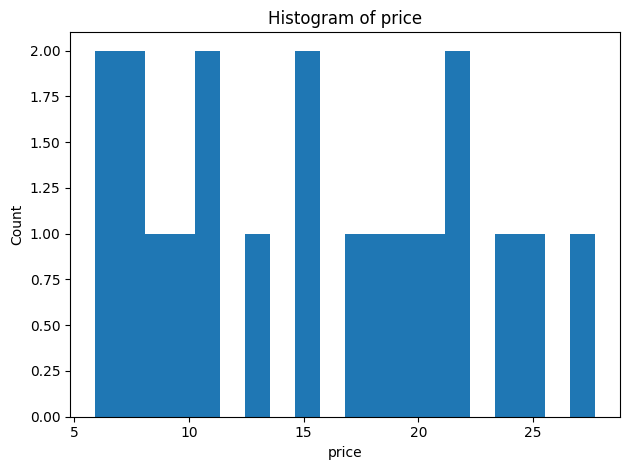


FINAL ANSWER:
 <think>
Okay, let me see. The user asked to read the top 5 rows from the CSV file and then plot a histogram of the 'price' column. 

First, I called the 'read_head' function with path './demo_sales.csv' and n=5. The response was "Displayed preview," which means that worked. Then, I used 'plot_histogram' with the same path, column 'price', and bins=20. The response was "Displayed histogram." So both steps were successful.

Now, the user probably wants confirmation that both actions were completed. Since the tools returned success messages, I should inform them that the preview is shown and the histogram is rendered. Maybe add a note that they can ask for more details if needed. Keep it concise and clear.
</think>

The first 5 rows of `./demo_sales.csv` have been previewed, and a histogram for the `price` column has been rendered. Let me know if you'd like to explore further!


In [31]:
agent = run_app(
    "Read the top 5 rows from './demo_sales.csv', then plot a histogram of 'price'. "
)

for m in agent:
    if isinstance(m, AIMessage) and not m.tool_calls:
        print("\nFINAL ANSWER:\n", m.content)